In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregar os dados de natureza
df_natureza_transacao_qtd = pd.read_csv(r"data\natureza_transaocao_qtd.csv") # qtd (mil)
df_natureza_transacao_valor = pd.read_csv(r"data\natureza_transaocao_valor.csv") # valor (R$ mil)

# Carregar os dados de iniciações
df_transacao_iniciacao_qtd = pd.read_csv(r"data\transacoes_iniciacao_qtd.csv", sep=';') # qtd (mil)
df_transacao_iniciacao_valor = pd.read_csv(r"data\transacoes_iniciacao_valor.csv", sep=';') # valor (R$ mil)


In [ ]:
# Configuração para leitura correta (ajustando o separador e limpando aspas)
def carregar_dados_limpos(path):
    df = pd.read_csv(path, sep=';', decimal=',', thousands='.', quotechar='"')
    # Ajustar DateTime
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    # Garantir que todas as colunas (exceto data) sejam numéricas
    for col in df.columns:
        if col != 'DateTime':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.sort_values('DateTime')

In [ ]:
# Carregando os dados limpos
df_nat_qtd = carregar_dados_limpos(r"data\natureza_transaocao_qtd.csv")
df_nat_valor = carregar_dados_limpos(r"data\natureza_transaocao_valor.csv")
df_ini_qtd = carregar_dados_limpos(r"data\transacoes_iniciacao_qtd.csv")
df_ini_valor = carregar_dados_limpos(r"data\transacoes_iniciacao_valor.csv")

#### **Questão 1 — Raciocínio Analítico**

In [24]:
# --- ANÁLISE 1: Crescimento por Natureza ---
# Calculando a variação percentual do último mês em relação ao primeiro
primeiro_mes = df_nat_qtd.iloc[0, 1:]
ultimo_mes = df_nat_qtd.iloc[-1, 1:]
crescimento_nat = ((ultimo_mes - primeiro_mes) / primeiro_mes * 100).sort_values(ascending=False)

print("Crescimento por Natureza (% no período):")
print(crescimento_nat)

Crescimento por Natureza (% no período):
G2B    247.272727
G2G    189.473684
G2P     178.39851
B2G    160.299359
B2B    107.483128
P2G     83.380218
P2B     64.038352
B2P     52.488618
P2P     12.119496
dtype: object


In [32]:
# --- ANÁLISE 2: Ticket Médio por Iniciação ---
# Cruzando Qtd e Valor de iniciação para ver onde o dinheiro "pesado" está entrando
df_ini_valor = carregar_dados_limpos(r"data\transacoes_iniciacao_valor.csv")

ticket_medio_ini = (df_ini_valor.iloc[-1, 1:] / df_ini_qtd.iloc[-1, 1:]).sort_values(ascending=False)
print("\nTicket Médio por Forma de Iniciação (R$):")
print(ticket_medio_ini)


Ticket Médio por Forma de Iniciação (R$):
Inserção Manual                                    1567.846948
Pix Automático                                       744.93876
Chave Pix                                            548.28524
QR Code Estático                                    131.370222
QR Code Dinâmico                                     89.043992
Pix por aproximação                                  43.331958
Iniciado com todas as informações do recebedor             NaN
Iniciador com todas as informações do recebedor            NaN
Name: 13, dtype: object


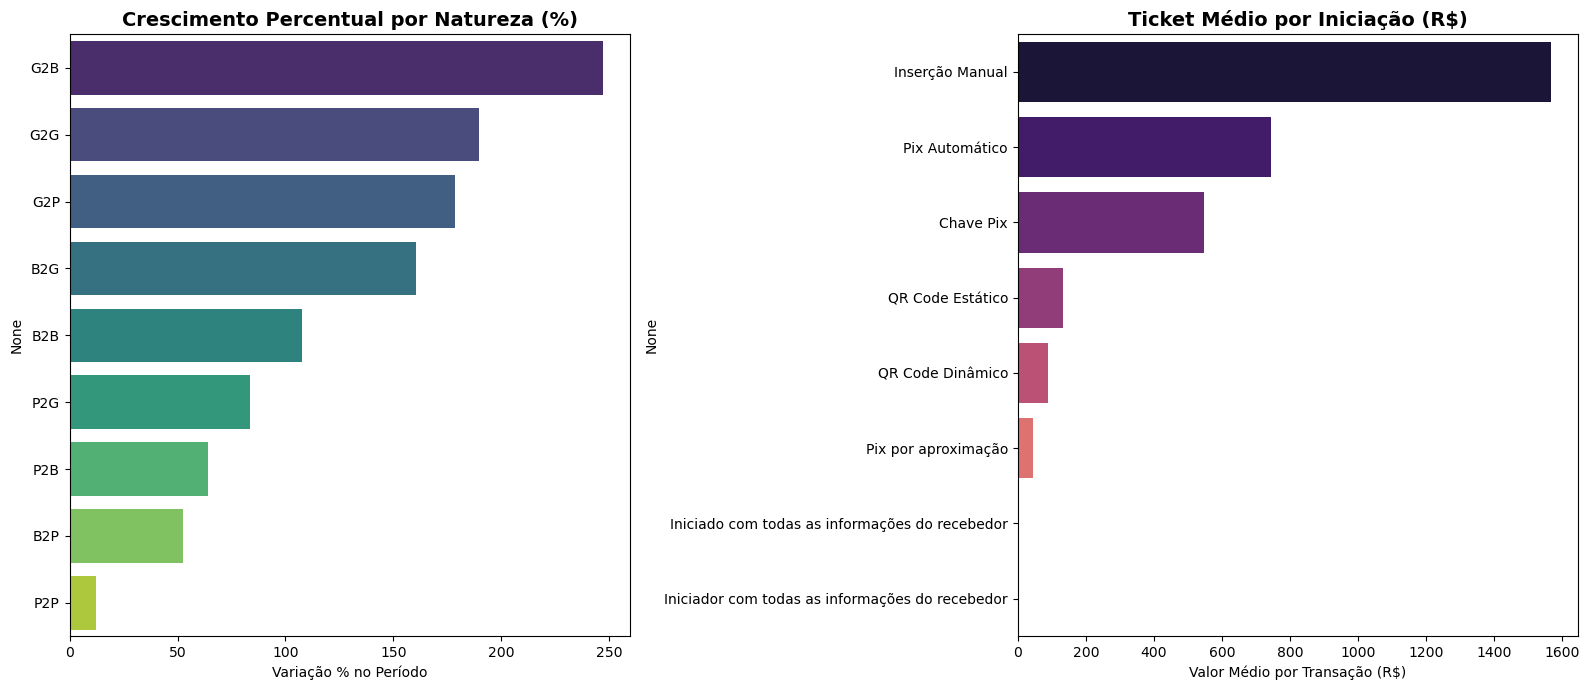

In [ ]:
# --- VISUALIZAÇÃO DOS DESTAQUES ---
# Criação do Subplot 
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico 1: Crescimento por Natureza
sns.barplot(
    x=crescimento_nat.values, 
    y=crescimento_nat.index, 
    ax=ax[0], 
    hue=crescimento_nat.index, 
    palette="viridis", 
    legend=False
)
ax[0].set_title('Crescimento Percentual por Natureza (%)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Variação % no Período')

# Gráfico 2: Ticket Médio por Iniciação
sns.barplot(
    x=ticket_medio_ini.values, 
    y=ticket_medio_ini.index, 
    ax=ax[1], 
    hue=ticket_medio_ini.index, 
    palette="magma", 
    legend=False
)
ax[1].set_title('Ticket Médio por Iniciação (R$)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Valor Médio por Transação (R$)')

plt.tight_layout()
plt.show()

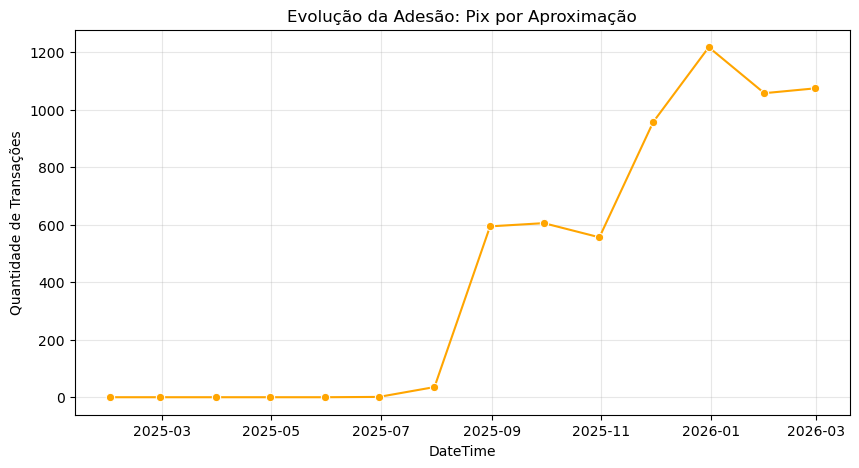

Crescimento Médio Mensal: inf%


In [38]:
# Filtrando a evolução do Pix por Aproximação
df_aprox = df_ini_qtd[['DateTime', 'Pix por aproximação']].copy()

# Calculando a variação percentual mês a mês
df_aprox['Crescimento_Mensal_%'] = df_aprox['Pix por aproximação'].pct_change() * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_aprox, x='DateTime', y='Pix por aproximação', marker='o', color='orange')
plt.title('Evolução da Adesão: Pix por Aproximação')
plt.ylabel('Quantidade de Transações')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Crescimento Médio Mensal: {df_aprox['Crescimento_Mensal_%'].mean():.2f}%")